In [12]:
import pandas as pd
import numpy as np

df=pd.read_csv("../data/analysis_results/nav_history_daily_returns.csv")

# Ensure daily_return exists
df = df.dropna(subset=["daily_return"])
risk_metrics=[]

for scheme,group in df.groupby('amfi_code'):
    returns=group['daily_return']

    if len(returns)<30:
        continue
    #calculating var(95%)
    var_95=np.percentile(returns,5)

    #calculating cvar
    cvar_95=returns[returns<=var_95].mean()

    risk_metrics.append({
            'amfi_code':scheme,
            'VaR_95':var_95,
            'CVaR_95':cvar_95
    })
    risk_df=pd.DataFrame(risk_metrics)
    risk_df.to_csv('../data/analysis_results/var_cvar_report.csv',index=False)
print(risk_df)



    amfi_code    VaR_95   CVaR_95
0      100016 -0.014364 -0.018060
1      100025 -0.003793 -0.004994
2      100033 -0.019034 -0.023456
3      101206 -0.013282 -0.017439
4      101207 -0.026021 -0.032459
5      101208 -0.000269 -0.000422
6      102885 -0.012613 -0.015490
7      102886 -0.019220 -0.023251
8      102887 -0.015232 -0.019411
9      118632 -0.013954 -0.017619
10     118633 -0.013443 -0.016630
11     118634 -0.025438 -0.032304
12     118635 -0.012554 -0.016177
13     118636 -0.003804 -0.004919
14     119092 -0.013750 -0.017328
15     119093 -0.014226 -0.017487
16     119094 -0.018480 -0.024260
17     119095 -0.026188 -0.031667
18     119120 -0.003938 -0.005014
19     119551 -0.012846 -0.016397
20     119552 -0.013501 -0.017336
21     119598 -0.024507 -0.030595
22     119599 -0.026859 -0.032384
23     120503 -0.013550 -0.017451
24     120504 -0.013728 -0.017494
25     120505 -0.018892 -0.024342
26     120506 -0.014388 -0.019405
27     120507 -0.000222 -0.000373
28     120841 

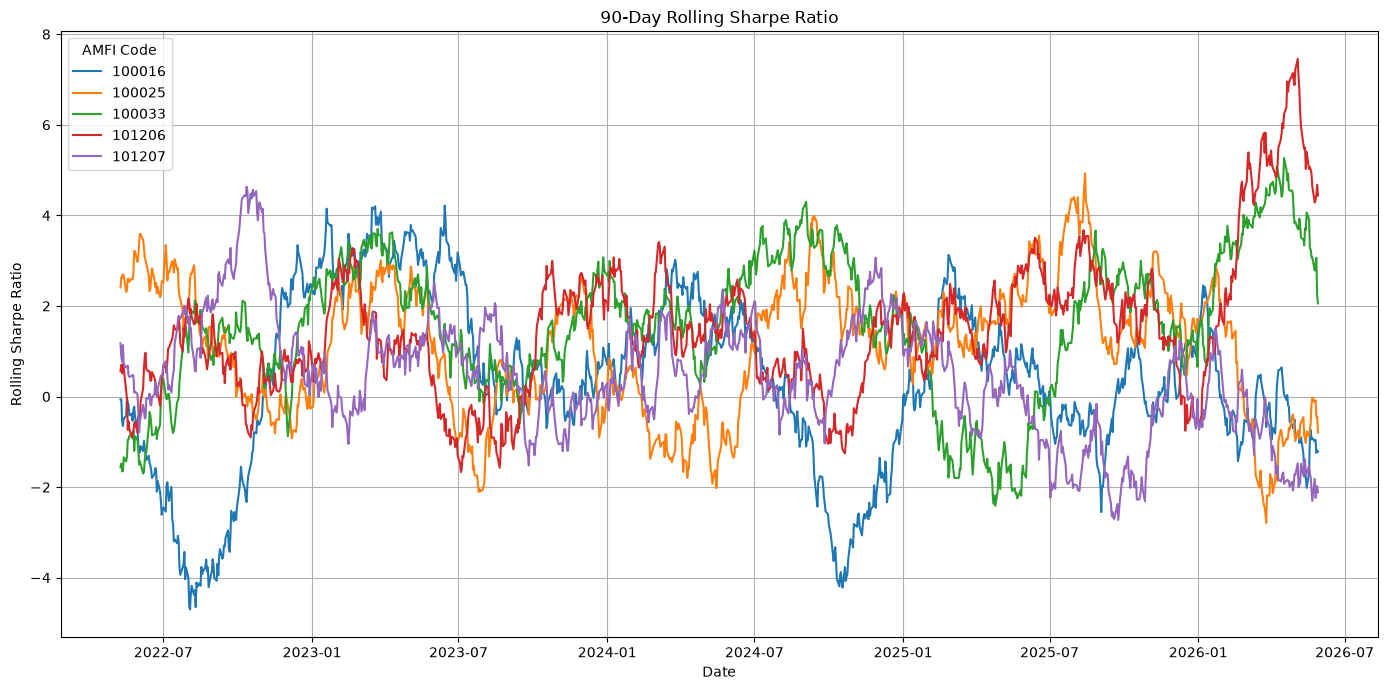

Rolling Sharpe Ratio saved to rolling_sharpe_90day.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/analysis_results/nav_history_daily_returns.csv')

# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Remove rows with missing daily returns
df = df.dropna(subset=["daily_return"])

# Sort by scheme and date
df = df.sort_values(["amfi_code", "date"])


key_funds = [
    100016,
    100025,
    100033,
    101206,
    101207
]

plt.figure(figsize=(14, 7))

# Store all rolling Sharpe values
all_results = []

# Calculate Rolling Sharpe Ratio


for fund in key_funds:

    # Filter one fund
    fund_data = df[df["amfi_code"] == fund].copy()

    # Skip if fund not found
    if fund_data.empty:
        print(f"Fund {fund} not found.")
        continue

    # Calculate rolling mean (90 days)
    rolling_mean = fund_data["daily_return"].rolling(window=90).mean()

    # Calculate rolling standard deviation (90 days)
    rolling_std = fund_data["daily_return"].rolling(window=90).std()

    # Annualized Rolling Sharpe Ratio
    fund_data["rolling_sharpe"] = (
        rolling_mean / rolling_std
    ) * np.sqrt(252)

    # Store results
    all_results.append(
        fund_data[["amfi_code", "date", "rolling_sharpe"]]
    )

    # Plot
    plt.plot(
        fund_data["date"],
        fund_data["rolling_sharpe"],
        label=str(fund)
    )

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend(title="AMFI Code")
plt.grid(True)
plt.tight_layout()

plt.show()



if all_results:
    output_df = pd.concat(all_results, ignore_index=True)
    output_df.to_csv("rolling_sharpe_90day.csv", index=False)
    print("Rolling Sharpe Ratio saved to rolling_sharpe_90day.csv")
else:
    print("No results to save.")

In [ ]:
import pandas as pd

df = pd.read_csv("../data/processed/clean_investor_transactions.csv")


# Convert transaction date to datetime
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

# Keep only investments (exclude redemptions if desired)
df = df[df["transaction_type"].isin(["SIP", "Lumpsum"])]


# Find each investor's first transaction date
first_txn = (
    df.groupby("investor_id")["transaction_date"]
      .min()
      .reset_index()
)

# Extract first transaction year
first_txn["cohort_year"] = first_txn["transaction_date"].dt.year

# Merge cohort year back into original dataframe
df = df.merge(
    first_txn[["investor_id", "cohort_year"]],
    on="investor_id",
    how="left"
)


# Average SIP Amount

sip_df = df[df["transaction_type"] == "SIP"]

avg_sip = (
    sip_df.groupby("cohort_year")["amount_inr"]
          .mean()
          .reset_index(name="avg_sip_amount")
)

# Total Invested
total_invested = (
    df.groupby("cohort_year")["amount_inr"]
      .sum()
      .reset_index(name="total_invested")
)

# Top Fund Preference

scheme_df = pd.read_csv("../data/processed/clean_scheme_performance.csv")
transactions = df.merge(
    scheme_df[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)
fund_counts = (
    transactions.groupby(["cohort_year", "scheme_name"])
      .size()
      .reset_index(name="count")
)

top_fund = (
    fund_counts.sort_values(
        ["cohort_year", "count"],
        ascending=[True, False]
    )
    .groupby("cohort_year")
    .first()
    .reset_index()
)

top_fund = top_fund.rename(
    columns={
        "scheme_name": "top_fund_preference"
    }
)

# Combine Results
cohort_analysis = (
    avg_sip
    .merge(total_invested, on="cohort_year")
    .merge(
        top_fund[["cohort_year", "top_fund_preference"]],
        on="cohort_year"
    )
)

print(cohort_analysis)
cohort_analysis.to_csv(
    "investor_cohort_analysis.csv",
    index=False
)

print("\nInvestor cohort analysis saved successfully.")

   cohort_year  avg_sip_amount  total_invested  \
0         2024    11000.685231      2250893963   
1         2025    12593.189815        26160976   

                                 top_fund_preference  
0  HDFC Mid-Cap Opportunities Fund - Direct - Growth  
1           ICICI Pru Liquid Fund - Regular - Growth  

Investor cohort analysis saved successfully.


In [ ]:
df=pd.read_csv("../data/processed/clean_investor_transactions.csv")
df=df[df['transaction_type']=='SIP']
df['transaction_date']=pd.to_datetime(df['transaction_date'])
results=[]
for investor, group in df.groupby("investor_id"):
 if len(group)>=6:

  group=group.sort_values('transaction_date')
  gaps=group['transaction_date'].diff().dt.days
  avg_gap=gaps.mean()
  if avg_gap >35:
   status='risk'
  else:
   status='normal'
  results.append({'investor_id':investor,
                'sip_count':len(group),
                'average_gap_days':avg_gap,
                'status':status})
sip_analysis=pd.DataFrame(results)
sip_analysis.to_csv("../data/analysis_results/sip_analysis.csv",index=False)
print(sip_analysis.head())



  investor_id  sip_count  average_gap_days status
0   INV000004          6         85.400000   risk
1   INV000008          6         70.400000   risk
2   INV000010          6         64.800000   risk
3   INV000011          7         40.166667   risk
4   INV000012          8         57.000000   risk


In [35]:
print(sip_analysis["status"].value_counts())

status
risk      1332
normal      30
Name: count, dtype: int64


In [58]:
import pandas as pd

df = pd.read_csv("../data/processed/clean_scheme_performance.csv")

df = df[["scheme_name", "risk_grade", "sharpe_ratio"]]

# Remove missing values
df = df.dropna(subset=["risk_grade", "sharpe_ratio"])

# Remove duplicate schemes (if any)
df = df.drop_duplicates(subset=["scheme_name"])

risk = input("Enter Risk Appetite (Low / Moderate / High): ").strip().title()

valid_risk = ["Low", "Moderate", "High"]

if risk not in valid_risk:
    print("\nInvalid Risk Appetite!")
    print("Please enter: Low, Moderate or High")

else:

    recommendations = df[df["risk_grade"] == risk]
    recommendations = recommendations.sort_values(
        by="sharpe_ratio",
        ascending=False
    )

    top3 = recommendations.head(3)
    print("\n")
    print("=" * 65)
    print(f"Top 3 Recommended Funds for {risk} Risk Investors")
    print("=" * 65)

    print(
        top3[
            [
                "scheme_name",
                "risk_grade",
                "sharpe_ratio"
            ]
        ].to_string(index=False)
    )
    top3.to_csv(
        "../data/analysis_results/fund_recommendations.csv",
        index=False
    )

    print("\nRecommendations saved successfully!")



Top 3 Recommended Funds for Low Risk Investors
                             scheme_name risk_grade  sharpe_ratio
ICICI Pru Liquid Fund - Regular - Growth        Low          7.68
    Kotak Liquid Fund - Regular - Growth        Low          6.18
     ABSL Liquid Fund - Regular - Growth        Low          5.14

Recommendations saved successfully!


    amfi_code                                        scheme_name       HHI  \
11     119092              Axis Bluechip Fund - Regular - Growth  0.296769   
30     148569      Mirae Asset Tax Saver Fund - Regular - Growth  0.254992   
27     125498  HDFC Mid-Cap Opportunities Fund - Direct - Growth  0.253155   
6      102887              UTI Flexi Cap Fund - Regular - Growth  0.251383   
32     149323                 DSP Midcap Fund - Regular - Growth  0.241077   
21     120505           ICICI Pru Midcap Fund - Regular - Growth  0.238695   
10     118635                     Nippon India ETF Nifty 50 BeES  0.237497   
18     119599          SBI Small Cap Fund - Direct Plan - Growth  0.232361   
22     120506  ICICI Pru Value Discovery Fund - Regular - Growth  0.231464   
1      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.227647   
16     119552           SBI Bluechip Fund - Direct Plan - Growth  0.227508   
3      101207             ABSL Small Cap Fund - Regular - Growth

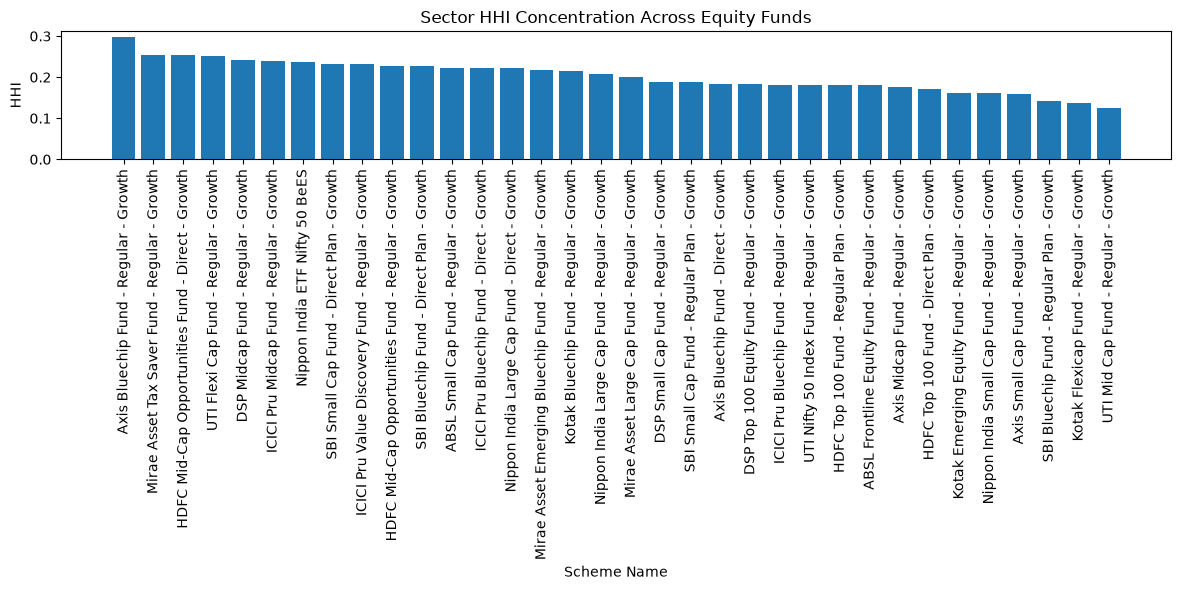


Sector HHI analysis saved successfully.


In [52]:
import pandas as pd
import matplotlib.pyplot as plt
portfolio_df= pd.read_csv("../data/raw/09_portfolio_holdings.csv")
scheme_df = pd.read_csv("../data/processed/clean_scheme_performance.csv")
df  = portfolio_df.merge(
    scheme_df[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)


df= df[["amfi_code", "scheme_name", "sector", "weight_pct"]]

# Remove missing values
df = df.dropna(subset=["weight_pct", "sector"])
# Convert Percentage to Decimal
df["weight"] = df["weight_pct"] / 100

# Calculate Sector Weights
# (In case a sector has multiple stocks)
sector_weights = (
    df.groupby(["amfi_code", "scheme_name", "sector"])["weight"]
      .sum()
      .reset_index()
)
# Calculate HHI for Each Fund

hhi = (
    sector_weights.groupby(["amfi_code", "scheme_name"])["weight"]
    .apply(lambda x: (x ** 2).sum())
    .reset_index(name="HHI")
)
# Classify Concentration
def classify_hhi(value):
    if value < 0.15:
        return "Well Diversified"
    elif value < 0.25:
        return "Moderately Concentrated"
    else:
        return "Highly Concentrated"

hhi["concentration"] = hhi["HHI"].apply(classify_hhi)
# Sort Funds by HHI
hhi = hhi.sort_values("HHI", ascending=False)
print(hhi)

hhi.to_csv(
    "../data/analysis_results/sector_hhi_concentration.csv",
    index=False
)

plt.figure(figsize=(12, 6))

plt.bar(
    hhi["scheme_name"],
    hhi["HHI"]
)

plt.xticks(rotation=90)
plt.xlabel("Scheme Name")
plt.ylabel("HHI")
plt.title("Sector HHI Concentration Across Equity Funds")

plt.tight_layout()
plt.show()

print("\nSector HHI analysis saved successfully.")

In [57]:
scheme_df = pd.read_csv("../data/processed/clean_scheme_performance.csv")

print(
    scheme_df.loc[
        scheme_df["amfi_code"] == 118635,
        ["amfi_code", "scheme_name"]
    ]
)

    amfi_code                     scheme_name
18     118635  Nippon India ETF Nifty 50 BeES
